# DS 3000 - Assignment 6

**Student Name**: Gauri Rajesh

**Date**: 6/14/2025


### Submission Instructions
Submit this `ipynb` file to canvas.

The `ipynb` format stores outputs from the last time you ran the notebook.  (When you open a notebook it has the figures and outputs of the last time you ran it too).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh run `Kernel > Restart & Run All` just before uploading the `ipynb` file to Canvas.

### Academic Integrity

**Writing your homework is an individual effort.**  You may discuss general python problems with other students but under no circumstances should you observe another student's code which was written for this assignment, from this year or past years.  Pop into office hours or DM us in MS Teams if you have a specific question about your work or if you would like another pair of eyes or talk through your code.

Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment. You do not need to cite the official python documentation.

**Documentation / style counts for credit**  Please refer to the Pep-8 style, to improve the readability and consistency of your Python code. For more information, read the following article [How to Write Beautiful Python Code With PEP 8](https://realpython.com/python-pep8/) or ask your TA's for tips.

**NOTE:<span style='color:red'> Write python expressions to answer ALL questions below and ensure that you use the `print()` function to display the output.</span>** Each question should be answered in a new code cell. For example, your solution for question 1.1 should be in a different code cell from your solution for question 1.2.

## Question 1: 

TODO: Create a SVM classifier to predict the onset of diabetes using the Pima Indians Diabetes Database. Information on the Pima Indians Diabetes Database can be obtained directly from kaggle.com. The link also contains the description of each field in the dataset.


**Part A:** Load the dataset “diabetes.csv”, view the dimensions of the data, and gather summary statistics. Comment on your observations about the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

# load dataset
df = pd.read_csv('diabetes.csv')

# inspect head
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [2]:
# inspect dimensions
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 768 rows and 9 columns.


In [3]:
# inspect data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


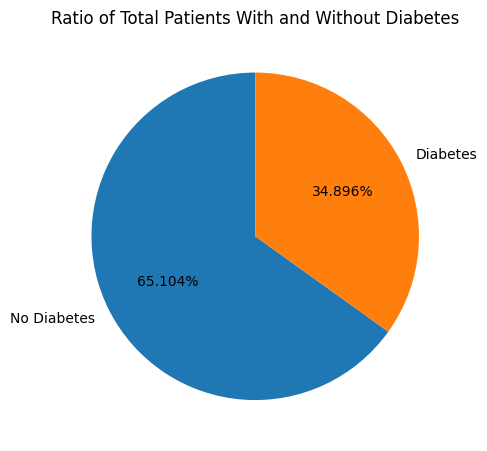

In [4]:
# gather summary statistics

# ratio of outcomes
plt.subplots(figsize=(5,5))
outcomes_df = df.groupby('Outcome')['Outcome'].size()
outcomes_df.plot.pie(y='Outcomes', labels=['No Diabetes', 'Diabetes'],
                     autopct='%1.3f%%', startangle=90)
plt.title('Ratio of Total Patients With and Without Diabetes')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Analysis:**
<br></br>
Based on the above pie chart, a majority of patients in the dataset do not have diabetes.  65.104% of patients do not have diabetes, while 34.896% of patients have diabetes in the dataset.

In [5]:
# basic statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Analysis:**
<br></br>
Based on the summary statistics of the overall dataset, the average plasma glucose concentration is 120.89 mg/dL, which is considered normal as it is below 140 mg/dL.  This value tends to vary by about 31.97 mg/dL based on the standard deviation.  Values above the 75 percentile mark would be considered high.  The average diastolic blood pressure is 20.54 mm Hg, which is considered normal as it is below 80 mm Hg.  This value tends to vary by about 19.36 mm Hg based on the standard deviation.  Values above the 75 percentile mark would be considered high.  The average insulin level is 79.8 muU/ml and this varies significantly by 115.24 muU/ml based on the standard deviation.  This is likely due to other factors such as age, gender, and race (John, 2024).  The average BMI is 31.99, which is considered obese.  BMI values below the 25 percentile of 27.3 are considered to be in the healthy range.  BMI vaues above the 50 percentile are considered to be in the obesity or even severe obesity range if above 40.  The diabetes pedigree function has an average value of 0.47, which can vary by 0.33 based on the standard deviation.  The average age of patients in the dataset is about 33, and this tends to vary by about 11 years in the dataset.  The youngest patient in the dataset is 21 and the oldest patient in the dataset is 81.  

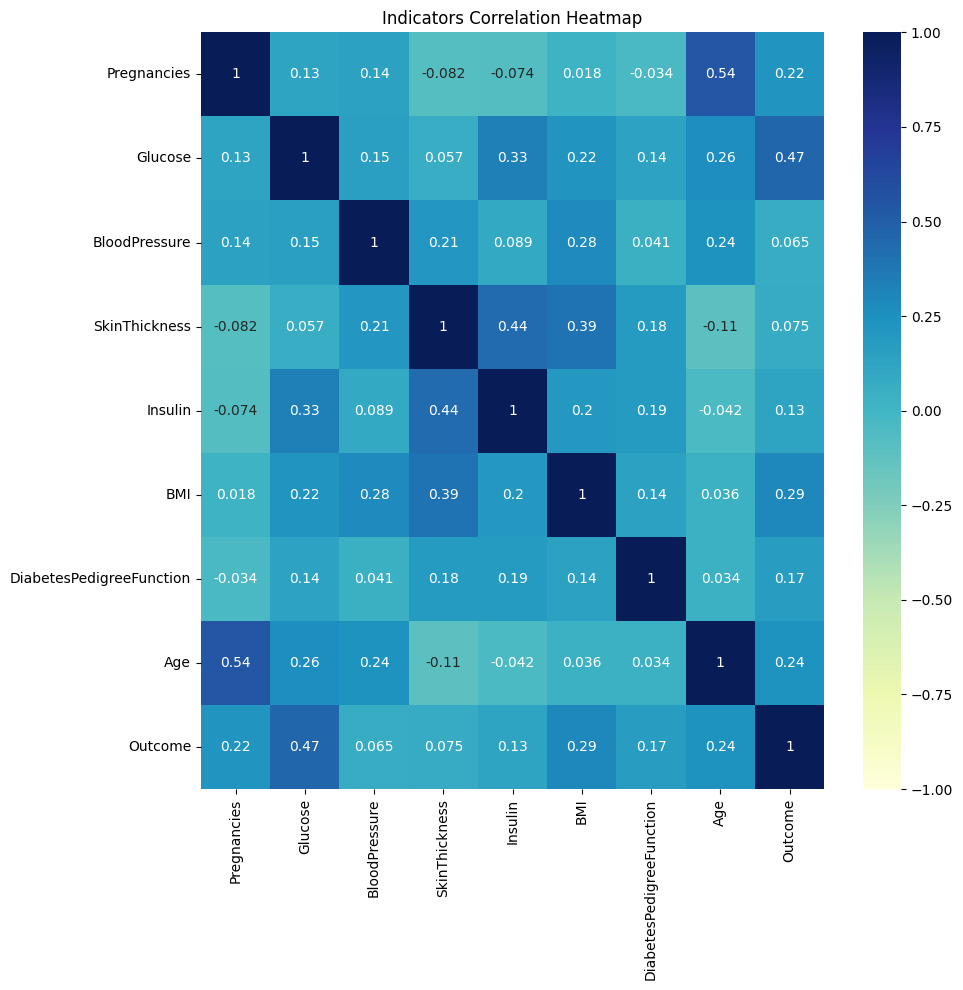

In [6]:
# check for correlations
correlation_matrix = df.corr()
plt.subplots(figsize=(10,10))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', vmin=-1, vmax=1)
plt.title("Indicators Correlation Heatmap")
plt.tight_layout()
plt.show()

**Analysis:**
<br></br>
Based on the above correlation matrix, plasma glucose concentration, BMI, and age demonstrate the highest correlations with diabetes outcome with values of 0.47, 0.29, and 0.24 respectively.  Plasma glucose concentration demonstrates a moderate positive correlation with diabetes outcomes, whereas the other predictor variables demonstrate weak positive correlations.  2-hour serum insulin levles (muU/ml), BMI, and age demonstrate weak positive correlations with glucose levels.

**Observations:**
<br></br>
Based on the summary statistics and correlation matrix, a majority of patients in the dataset do not have diabetes.  The medical predictors with the greatest correlation with the diabetes outcome variable are plasma glucose concentration, BMI, and age.  While plasma glucose concentration does have a moderate positive correlation with diabetes, the other medical predictors demonstrate weaker positive correlations.  This indicates that no single independent variable has a strong correlation with diabetes onset in the dataset, likely due to the complex effects of various factors such as age, gender, and BMI.   

**Part B:**  Create two visualizations that demonstrate univariate and/or pairwise patterns in the data. Comment on the patterns.

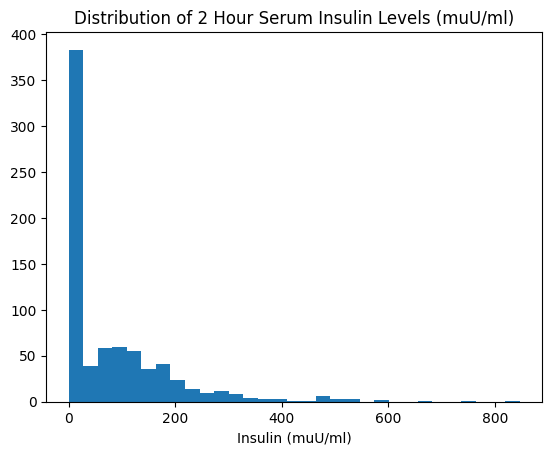

In [7]:
# univariate patterns: 
plt.hist(df['Insulin'], bins='auto')
plt.title('Distribution of 2 Hour Serum Insulin Levels (muU/ml)')
plt.xlabel('Insulin (muU/ml)')
plt.show()

**Analysis:**
<br></br>
Based on the above histogram, data on 2 hour serum insulin levels is heavily right skewed as a majority of insulin values are between 0 and 200 muU/ml.  The peak at 0-60 muU/ml indicates that a significant number of patients in the dataset have very low insulin values.  There are also likely some outliers in the range betwen 400 and 800 muU/ml as seen by the smaller peaks.

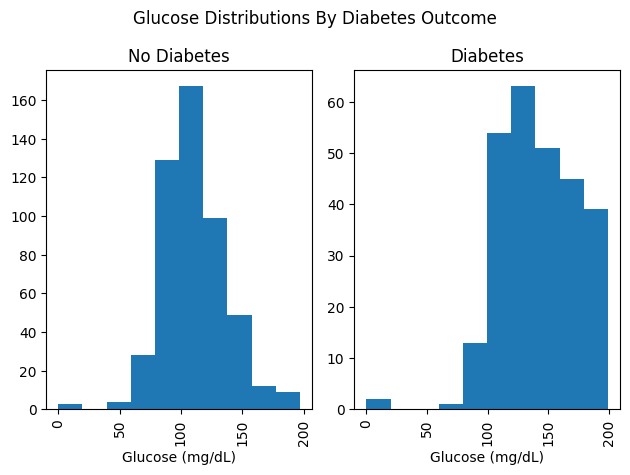

In [8]:
# pairwise patterns: plasma glucose concentration and outcome
axes = df.hist(column='Glucose', by='Outcome')
plt.suptitle('Glucose Distributions By Diabetes Outcome')
axes[0].set_xlabel('Glucose (mg/dL)')
axes[1].set_xlabel('Glucose (mg/dL)')
axes[0].set_title('No Diabetes')
axes[1].set_title('Diabetes')
plt.tight_layout()
plt.show()

**Analysis:**
<br></br>
Based on the above histograms, the mode or peak values for patients with no diabetes is 100 to 110 mg/dL and 120 to 140 mg/dL for patients with diabetes.  A majority of patients without diabetes have a plasma glucose concentration between 60 and 150 mg/dL.  A majority of patients with diabetes have a plasma glucose concentration between 75 and 200 mg/dL.  Therefore, patients with diabetes tend to have higher levels of plasma glucose concentrations.  Therefore, glucose is likely a strong indicator of diabetes outcomes.  There are no signficant skews in either histogram to note.

**Part C:**  Evaluate the data for missing or invalid values. Then prepare the data, and ensure that you handle missing and invalid values (if they exist).

In [9]:
# handle missing values

# display percentage of missing values for each feature
df.isnull().mean()*100

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

Based on this information, none of the variables have missing values in the dataset.  Therefore, missing values do not need to be deleted or imputed for this dataset.

In [10]:
# handle invalid values

# drop entries with BMI of 0
print(f"{df[df['BMI'] == 0].shape[0]} rows with BMI value of 0 before cleaning.")
df = df[df['BMI'] != 0]

# verify changes
print(f"{df[df['BMI'] == 0].shape[0]} rows with BMI value of 0 after cleaning.")

11 rows with BMI value of 0 before cleaning.
0 rows with BMI value of 0 after cleaning.


In [11]:
# drop entries with glucose levels of 0
print(f"{df[df['Glucose'] == 0].shape[0]} rows with Glucose value of 0 before cleaning.")
df = df[df['Glucose'] != 0]


# verify changes
print(f"{df[df['Glucose'] == 0].shape[0]} rows with Glucose value of 0 after cleaning.")

5 rows with Glucose value of 0 before cleaning.
0 rows with Glucose value of 0 after cleaning.


In [12]:
# drop entries with diastolic blood pressure levels of 0
print(f"{df[df['BloodPressure'] == 0].shape[0]} rows with Blood Pressure value of 0 before cleaning.")
df = df[df['BloodPressure'] != 0]


# verify changes
print(f"{df[df['BloodPressure'] == 0].shape[0]} rows with Blood Pressure value of 0 after cleaning.")

28 rows with Blood Pressure value of 0 before cleaning.
0 rows with Blood Pressure value of 0 after cleaning.


In [13]:
# drop entries with DiabetesPedigreeFunction values of 0
print(f"{df[df['DiabetesPedigreeFunction'] == 0.0].shape[0]} rows with DiabetesPedigreeFunction value of 0 before cleaning.")
df = df[df['DiabetesPedigreeFunction'] != 0.0]

# verify changes
print(f"{df[df['DiabetesPedigreeFunction'] == 0.0].shape[0]} rows with DiabetesPedigreeFunction value of 0 after cleaning.")

0 rows with DiabetesPedigreeFunction value of 0 before cleaning.
0 rows with DiabetesPedigreeFunction value of 0 after cleaning.


**Part D:**  Partition the data into train/test sets. After which, perform the following:
<li>encode any categorical data</li>
<li>normalize numeric data.</li>

**Tip:** Ensure that you use sklearn to normalize and/or encode the training data, after which transform the test set (there is an example in the lecture).



In [14]:
# partition data into train/test sets
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=7,
                                                    stratify=y)

In [15]:
# normalize numeric data
scaler = StandardScaler()
features_to_scale = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
scaler.fit(X_train[features_to_scale])

X_train[features_to_scale] = scaler.transform(X_train[features_to_scale])

In [16]:
# transform test set
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

**Part E:**  Build the model that predicts the target variable. Ensure that you:
<li>Instantiate the correct SVM model, train and evaluate it</li>
<li>Use GridSearchCV to tune at least two hyperparameters.**</li>
<li>Perform cross validation.</li>
<li>Display: the best model/parameters and the best score that was obtained</li>

**You'll need to read the documentation of the SVM algorithm to identify the hyperparameters.
**Tip:** Ensure that you use sklearn to normalize and/or encode the training data, after which transform the test set (there is an example in the lecture).

In [17]:
# instantiate SVM
svm = SVC()
svm.fit(X_train, y_train)

# make predictions and evaluate performance
y_pred = svm.predict(X_test)
print(f'The accuracy of the model is: {svm.score(X_test, y_test)}')
print(f'The predicted diabetes outcomes are {y_pred}.')

# classification report
print(classification_report(y_test, y_pred))

The accuracy of the model is: 0.7110091743119266
The predicted diabetes outcomes are [1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0 1
 1 0 1 0 0 1 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1
 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0
 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0].
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       143
           1       0.60      0.49      0.54        75

    accuracy                           0.71       218
   macro avg       0.68      0.66      0.66       218
weighted avg       0.70      0.71      0.70       218



The initial SVM model has an accuracy of 71.1%.

In [18]:
# use GridSearchCV to tune at least two hyperparameters
params = {'C': [0.1, 1, 10, 100, 1000], 
          'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
          'kernel': ['rbf', 'linear']}
svm = SVC()
svm_grid = GridSearchCV(svm, params, refit=True, cv=5, return_train_score=True)
svm_grid.fit(X_train, y_train)

print(svm_grid.best_params_)
print(svm_grid.best_score_)
print(svm_grid.best_estimator_.get_params())

{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
0.7866433702193749
{'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


Based on the GridSearchCV results, the best model parameters are a C value of 1, gamma value of 0.01, and kernel of 'rbf' instead of 'linear'.

In [19]:
# make predictions and evaluate performance of tuned model
y_pred = svm_grid.predict(X_test)
print(f'The accuracy of the model is: {svm_grid.score(X_test, y_test)}')
print(f'The predicted diabetes outcomes are {y_pred}.')

# classification report
print(classification_report(y_test, y_pred))

The accuracy of the model is: 0.7385321100917431
The predicted diabetes outcomes are [1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0 1
 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0].
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       143
           1       0.67      0.48      0.56        75

    accuracy                           0.74       218
   macro avg       0.71      0.68      0.69       218
weighted avg       0.73      0.74      0.73       218



The tuned model achieved an accuracy of 73.85%, 2.75% greater than the original model.

**Part F:**   Evaluate the scores from GridSearchCV for the training set and the test set to diagnose any bias-variance problems. Comment on the quality of the model. Did it accurately predict the target? Do you think the prediction from this model is useful and would you advocate for its use in the medical industry?

In [20]:
# diagnose any bias-variance problems
cv_results = pd.DataFrame(svm_grid.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)
cv_results[['mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']].head()

,mean_train_score,std_train_score,mean_test_score,std_test_score
38,0.793974,0.005020,0.786643,0.041302
14,0.794469,0.005625,0.786643,0.041302
26,0.794466,0.005030,0.784663,0.040269
1,0.786068,0.008901,0.782683,0.048910
3,0.786068,0.008901,0.782683,0.048910


**Analysis:**
<br></br>
Based on the table above, there is minimal variation between average train and test scores.  The train and test scores are both around 79-80%, indicating the model generalized well.  While the standard deviation for the train scores are low with values between 0.005 and 0.009, the standard deviation for the test scores are higher with values around 0.04.  This indicates that the model is stable on the training data but may demonstrate mild overfitting as there is some inconsistency in the test predictions.
<br></br>
**Potential Usage:**
<br></br>
In order for a model to be used appropriately in medical settings, it must not only have a high precision but also a high recall to predict disease onset in a majority of patients.  Based on the classification report, the model had a 76% precision for predicting patients without diabetes and 67% for predicting patients with diabets.  The model predicted 87% of all patients with no diabetes but only 48% of all patients with diabetes.  Therefore, while the overall accuracy of the model was about 74%, I would not advocate for the immediate use of this model without further tuning based on the lower recall and f1-score for diabetes patients.

## Helpful Resources 
**NOTE:** resources listed below were used in summary statistics and EDA to better understand values/units of various variables such as insulin and BMI.

https://www.ncbi.nlm.nih.gov/books/NBK532915/

https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings

https://www.nhsinform.scot/healthy-living/food-and-nutrition/healthy-eating-and-weight-management/body-mass-index-bmi/#:~:text=BMI%20ranges&text=between%2018.5%20and%2024.9%20%E2%80%93%20This,is%20described%20as%20severe%20obesity

https://dergipark.org.tr/en/download/article-file/1970853#:~:text=The%20'DiabetesPedigreeFunction'%20is%20a%20function,1%20represents%20those%20with%20diabetes.

